## Numerical schemes

When solving a PDE numerically with the **finite difference method**, the first step is to rewrite the PDE on a discrete grid by replacing its partial derivatives with **difference formulas**. These approximations may be **forward**, **backward**, or **centered** in space and/or time.

The specific combination chosen for approximating the spatial and temporal derivatives is called a **numerical scheme**.

### Main classes of schemes

Schemes are usually grouped into the following categories:

- **Explicit schemes:**  
  The solution at the **next time level** is obtained directly from values at the **current time level** (and possibly current-time values of other variables). No coupled system needs to be solved for the new time step.

- **Implicit schemes:**  
  The solution at the **next time level** depends on unknown values at that same next time level at other grid points. As a result, one typically must solve a set of algebraic equations at each time step.

- **Semi-implicit schemes:**  
  These lie in between the above two. In such methods, the future-time value of a variable may depend on future-time values of other variables, while some terms are still treated explicitly.

### Choosing an appropriate scheme

The choice of scheme is not made randomly. For a given PDE, the scheme must be checked for **stability**

## One-dimensional advection equation

The **one-dimensional advection (transport) equation** is

$$
\frac{\partial u}{\partial t}+c\,\frac{\partial u}{\partial x}=0,
$$

where $u(x,t)$ is a quantity being transported (for example, temperature or concentration) and $c$ is a constant transport speed. The equation states that the shape of $u$ is **carried along** the $x$-direction without changing form: a profile moves to the right if $c>0$ and to the left if $c<0$. Along a path moving with the flow speed, $dx/dt=c$, the value of $u$ remains constant, i.e. $du/dt=0$.

Several finite-difference schemes can be used to approximate a partial differential equation, but they do not all behave well numerically. Some choices can lead to **computational instability**. In this section, a few representative schemes are considered in order to illustrate how instability can arise.

Let the velocity $u$ depend on time $t$ and one spatial coordinate $x$, i.e. $u=f(t,x)$. The total differential of $u$ is

$$
du=\frac{\partial u}{\partial t}\,dt+\frac{\partial u}{\partial x}\,dx.
$$

Dividing by $dt$ gives

$$
\frac{du}{dt}=\frac{\partial u}{\partial t}+\frac{\partial u}{\partial x}\,\frac{dx}{dt}.
$$

If the quantity $\dfrac{du}{dt}=0$, then

$$
\frac{\partial u}{\partial t}+c\,\frac{\partial u}{\partial x}=0
\tag{9.9}
$$

where

$$
c=\frac{dx}{dt}
$$



## Forward-in-time and centered-in-space (FTCS) scheme

A common first attempt to discretize the advection equation (9.9),
$$
\frac{\partial u}{\partial t}+c\,\frac{\partial u}{\partial x}=0,
$$
is the **forward-in-time, centered-in-space (FTCS)** scheme. Using a forward difference for time and a centered difference for space gives

$$
\frac{u(t+\Delta t,\,x)-u(t,\,x)}{\Delta t}
=
-c\,\frac{u(t,\,x+\Delta x)-u(t,\,x-\Delta x)}{2\Delta x}.
$$

Rearranging,

$$
u(t+\Delta t,\,x)
=
u(t,\,x)
-\frac{C}{2}\Big[u(t,\,x+\Delta x)-u(t,\,x-\Delta x)\Big],
\tag{9.10}
$$

where
$$
C=\frac{c\,\Delta t}{\Delta x}
$$
is the **Courant number**.

Equation (9.10) shows that the value of $u$ at location $x$ and the next time level $t+\Delta t$ is computed using only values from the current time level $t$ at the neighboring points $x+\Delta x$ and $x-\Delta x$. For this reason, FTCS is an **explicit** scheme.

However, for the linear advection equation it can be shown (for example via a Fourier/von Neumann analysis) that the wave amplitude increases with time, meaning the FTCS method is **unconditionally unstable** for this problem.

## Forward-in-time and upstream-in-space (upwind) scheme

For the advection equation (9.9),
$$
\frac{\partial u}{\partial t}+c\,\frac{\partial u}{\partial x}=0,
$$
an alternative to the centered spatial difference is the **upwind (upstream) spatial difference**. The idea is to choose the spatial stencil based on the sign of the advection speed $c$ so that information is taken from the upstream direction.

Using a forward difference in time and an upwind difference in space, we obtain:

- If $c>0$ (information travels to the right), use a **backward** difference in space:
$$
\frac{u(t+\Delta t,\,x)-u(t,\,x)}{\Delta t}
=
-c\,\frac{u(t,\,x)-u(t,\,x-\Delta x)}{\Delta x}.
\tag{9.11}
$$

- If $c<0$ (information travels to the left), use a **forward** difference in space:
$$
\frac{u(t+\Delta t,\,x)-u(t,\,x)}{\Delta t}
=
-c\,\frac{u(t,\,x+\Delta x)-u(t,\,x)}{\Delta x}.
\tag{9.12}
$$

### Stability (CFL condition)

A standard stability analysis shows that this upwind scheme is **conditionally stable**. The stability requirement is

$$
\frac{c\,\Delta t}{\Delta x}\le 1.
$$

This inequality is known as the **CFL (Courant–Friedrichs–Lewy) stability condition**. It implies that the time step $\Delta t$ must be sufficiently small compared to the spatial step $\Delta x$ (for a given wave speed $c$) in order for the numerical solution to remain stable.

On the other hand, a user often prefers the opposite choice: a **larger** time step $\Delta t$ to reduce computational cost, and a **smaller** spatial step $\Delta x$ to achieve higher resolution. The CFL restriction then creates a practical conflict between **efficiency** and **accuracy**. This motivates the use of alternative schemes that can better accommodate these goals, although typically with trade-offs (for example, increased numerical diffusion, reduced accuracy, or the need to solve implicit equations).

## Implicit schemes

A numerical scheme is called **explicit** when the value of a variable at the next time level depends only on values already known at the current time level (either of the same variable or other variables). In contrast, a scheme is **implicit** when the unknown value at the future time level depends on other **unknown values at that same future time level**, typically at neighboring grid points.

In a general one-dimensional setting, an implicit update can be viewed as
$$
u(t+\Delta t, x_i)=f\!\left(u(t+\Delta t, x_{i-1}),\,u(t+\Delta t, x_{i+1}),\,u(t, x_i),\,\phi(t,x_i)\right),
$$
where $i=2,3,\ldots,N-1$ and $N$ is the total number of grid points.

---

### Euler implicit method for the advection equation

Consider the advection equation (9.9),
$$
\frac{\partial u}{\partial t}+c\,\frac{\partial u}{\partial x}=0.
$$

Using a **forward difference in time** and a **centered difference in space**, but evaluating the spatial derivative at the **new** time level $t+\Delta t$, we obtain the implicit finite-difference form:
$$
\frac{u(t+\Delta t,x)-u(t,x)}{\Delta t}
=
-c\,\frac{u(t+\Delta t,x+\Delta x)-u(t+\Delta t,x-\Delta x)}{2\Delta x}.
$$

Rearranging and introducing the Courant number
$$
C=\frac{c\,\Delta t}{\Delta x},
$$
gives
$$
-\frac{C}{2}\,u(t+\Delta t,x-\Delta x)+u(t+\Delta t,x)+\frac{C}{2}\,u(t+\Delta t,x+\Delta x)=u(t,x).
$$

Using index notation ($u_i^n \equiv u(t_n,x_i)$), this becomes
$$
-\frac{C}{2}\,u_{i-1}^{\,n+1}+u_i^{\,n+1}+\frac{C}{2}\,u_{i+1}^{\,n+1}=u_i^{\,n},
\qquad i=2,3,\ldots,N-1.
$$

The boundary nodes $i=1$ and $i=N$ are handled separately using the specified boundary conditions, so the interior nodes produce **$N-2$ coupled algebraic equations** at each time step.

---

### Matrix form

For the interior unknowns, the system can be written as a tridiagonal matrix equation:
$$
\begin{bmatrix}
1 & \frac{C}{2} & 0 & \cdots & 0 \\
-\frac{C}{2} & 1 & \frac{C}{2} & \cdots & 0 \\
0 & -\frac{C}{2} & 1 & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & \frac{C}{2} \\
0 & \cdots & 0 & -\frac{C}{2} & 1
\end{bmatrix}
\begin{bmatrix}
u_2^{\,n+1}\\
u_3^{\,n+1}\\
u_4^{\,n+1}\\
\vdots\\
u_{N-1}^{\,n+1}
\end{bmatrix}
=
\begin{bmatrix}
u_2^{\,n}\\
u_3^{\,n}\\
u_4^{\,n}\\
\vdots\\
u_{N-1}^{\,n}
\end{bmatrix}.
\tag{9.14}
$$

---

### Solving and stability

This linear system can be solved to get the solution. A key advantage of the Euler implicit approach is that it is **unconditionally stable**, so it can allow larger time steps $\Delta t$ than explicit schemes. The trade-off is that each time step requires solving a coupled system, which increases the computational work per step—though it can still be efficient when long-time integration is needed because fewer time steps may be required overall.

C = 0.1


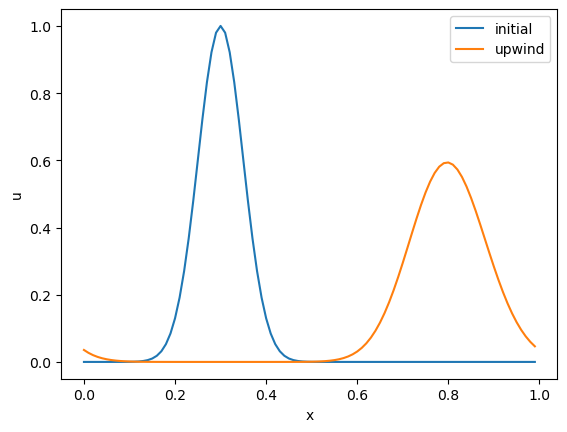

In [109]:
import numpy as np
import matplotlib.pyplot as plt

c = 1
L = 1.0
Nx = 100
dx = L / Nx
x = np.linspace(0, L, Nx, endpoint=False)

u0 = np.exp(-((x - 0.3) / 0.07)**2)

dt = 0.001
C = c * dt / dx
print("C =", C)

nsteps = 500   # total time = 0.5, shift = c*t = 0.5

u_up = u0.copy()

for n in range(nsteps):
    u_new = u_up.copy()
    for i in range(Nx):
        im = i - 1
        if im == -1:
            im = Nx - 1
        u_new[i] = u_up[i] - C * (u_up[i] - u_up[im])
    u_up = u_new

plt.plot(x, u0, label="initial")
plt.plot(x, u_up, label="upwind")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.show()